In [2]:
!pip install xgboost

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.svm import SVC

In [4]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', return_X_y=True,)
print(X.shape, y.shape)

(70000, 784) (70000,)


In [5]:
X.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197414,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.991206,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [6]:
X = X/255

In [7]:
X.values[0].shape 

(784,)

In [8]:
#convert the labels to integer 
y = y.astype(int)
#to get only one sample per each digit
num_digit = list(range(10))
sample = []

for num in num_digit:
    index = y[y == num].index[0]  #The first index where y == digit
    sample.append(index)

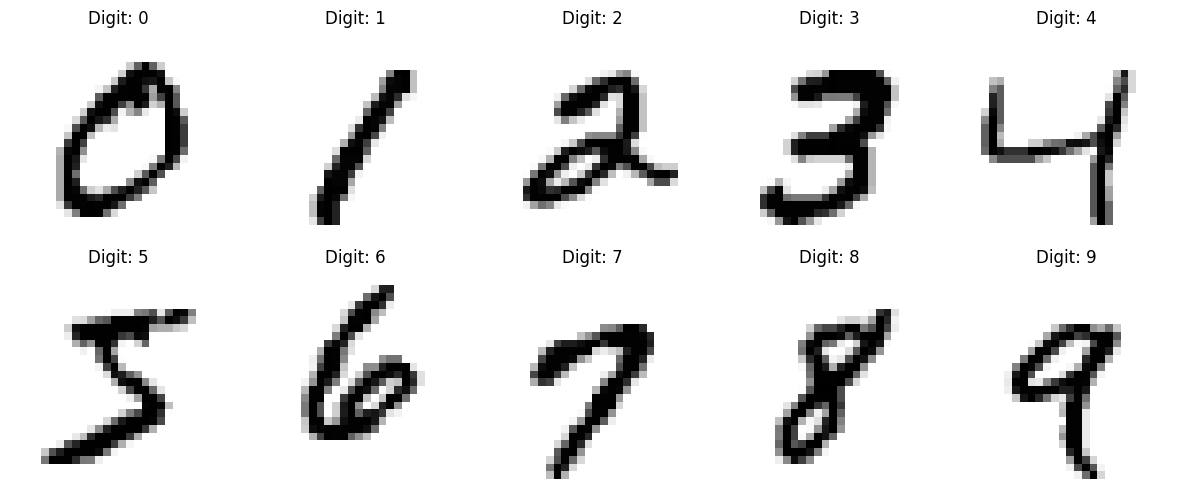

In [9]:
#Plot the digits
plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample):
    image_data = X.iloc[idx].values.reshape(28, 28)
    plt.subplot(2,5,i + 1)
    plt.imshow(image_data, cmap='gray_r')
    plt.title(f'Digit: {y.iloc[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
#split the data 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [12]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

#predictions
y_pred_log = model.predict(X_test)

print("Logistic Reg report:",classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Reg report:               precision    recall  f1-score   support

           0       0.95      0.97      0.96      2071
           1       0.95      0.97      0.96      2363
           2       0.91      0.90      0.91      2097
           3       0.89      0.89      0.89      2142
           4       0.92      0.92      0.92      2047
           5       0.89      0.87      0.88      1894
           6       0.94      0.95      0.95      2063
           7       0.93      0.94      0.94      2188
           8       0.90      0.88      0.89      2048
           9       0.89      0.89      0.89      2087

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000

Accuracy: 0.919


C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
#Decision Tree Classifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

#predictions
y_pred_dtc = dtc.predict(X_test)

print("Decision Tree report:",classification_report(y_test, y_pred_dtc))
print("Accuracy:", accuracy_score(y_test, y_pred_dtc))

Decision Tree report:               precision    recall  f1-score   support

           0       0.92      0.92      0.92      2071
           1       0.94      0.95      0.95      2363
           2       0.84      0.84      0.84      2097
           3       0.80      0.82      0.81      2142
           4       0.86      0.86      0.86      2047
           5       0.81      0.80      0.80      1894
           6       0.91      0.90      0.90      2063
           7       0.89      0.90      0.90      2188
           8       0.81      0.80      0.80      2048
           9       0.84      0.83      0.83      2087

    accuracy                           0.86     21000
   macro avg       0.86      0.86      0.86     21000
weighted avg       0.86      0.86      0.86     21000

Accuracy: 0.864


In [15]:
#Random Forest Classifier 
rfr = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfr.fit(X_train, y_train)

#Predection
y_pred_rfc = rfr.predict(X_test)

print("Random Forest report:",classification_report(y_test, y_pred_rfc))
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))

Random Forest report:               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.98      0.98      0.98      2363
           2       0.96      0.97      0.96      2097
           3       0.96      0.95      0.96      2142
           4       0.97      0.96      0.96      2047
           5       0.97      0.96      0.96      1894
           6       0.97      0.98      0.98      2063
           7       0.97      0.97      0.97      2188
           8       0.95      0.95      0.95      2048
           9       0.94      0.94      0.94      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

Accuracy: 0.9661904761904762


In [16]:
#SVC - Linear kernel
svc = SVC(kernel = 'linear') #linear 

svc.fit(X_train, y_train)

#predictions
y_pred_svcl = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_svcl)
print("SVC - linear report:",classification_report(y_test, y_pred_svcl))
print(f"Accuracy: {accuracy:.2f}")

SVC - linear report:               precision    recall  f1-score   support

           0       0.95      0.97      0.96      2071
           1       0.96      0.98      0.97      2363
           2       0.92      0.93      0.93      2097
           3       0.90      0.92      0.91      2142
           4       0.93      0.93      0.93      2047
           5       0.91      0.90      0.90      1894
           6       0.96      0.96      0.96      2063
           7       0.95      0.95      0.95      2188
           8       0.93      0.89      0.91      2048
           9       0.93      0.90      0.92      2087

    accuracy                           0.93     21000
   macro avg       0.93      0.93      0.93     21000
weighted avg       0.93      0.93      0.93     21000

Accuracy: 0.93


In [17]:
#SVC - sigmoid kernel
svc = SVC(kernel = 'sigmoid') #sigmoid 

svc.fit(X_train, y_train)

#predictions
y_pred_svcs = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_svcs)
print("SVC - sigmoid report:",classification_report(y_test, y_pred_svcs))
print(f"Accuracy: {accuracy:.2f}")

SVC - sigmoid report:               precision    recall  f1-score   support

           0       0.82      0.84      0.83      2071
           1       0.86      0.95      0.90      2363
           2       0.75      0.74      0.75      2097
           3       0.77      0.70      0.74      2142
           4       0.81      0.83      0.82      2047
           5       0.58      0.64      0.61      1894
           6       0.85      0.83      0.84      2063
           7       0.87      0.83      0.85      2188
           8       0.66      0.69      0.68      2048
           9       0.78      0.70      0.74      2087

    accuracy                           0.78     21000
   macro avg       0.78      0.77      0.77     21000
weighted avg       0.78      0.78      0.78     21000

Accuracy: 0.78


In [18]:
#SVC - poly kernel
svc = SVC(kernel = 'poly') 

svc.fit(X_train, y_train)

#predictions
y_pred_svcp = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_svcp)
print("SVC - poly report:",classification_report(y_test, y_pred_svcp))
print(f"Accuracy: {accuracy:.2f}")

SVC - poly report:               precision    recall  f1-score   support

           0       0.97      0.99      0.98      2071
           1       0.97      0.99      0.98      2363
           2       0.97      0.97      0.97      2097
           3       0.98      0.97      0.97      2142
           4       0.98      0.97      0.97      2047
           5       0.97      0.97      0.97      1894
           6       0.98      0.99      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.98      0.96      0.97      2048
           9       0.97      0.95      0.96      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

Accuracy: 0.97


In [19]:
#SVC - rbf kernel
svc = SVC(kernel = 'rbf') 

svc.fit(X_train, y_train)

#redictions
y_pred_svcrbf = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_svcrbf)
print("SVC - rbf report:",classification_report(y_test, y_pred_svcrbf))
print(f"Accuracy: {accuracy:.2f}")

SVC - rbf report:               precision    recall  f1-score   support

           0       0.98      0.99      0.99      2071
           1       0.98      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.97      2142
           4       0.98      0.97      0.97      2047
           5       0.98      0.97      0.98      1894
           6       0.98      0.99      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000

Accuracy: 0.98


In [20]:
#XGboost Classifier
XGB = XGBClassifier(eval_metric='mlogloss',random_state=42)

XGB.fit(X_train, y_train)

#prediction
y_pred_xgb = XGB.predict(X_test)

print("XGboost report:",classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGboost report:               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.99      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.98      2142
           4       0.98      0.96      0.97      2047
           5       0.98      0.97      0.97      1894
           6       0.97      0.98      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

Accuracy: 0.9749047619047619


# Model Evaluation

In [22]:
logreg_acc = accuracy_score(y_test, y_pred_log)
dt_acc = accuracy_score(y_test, y_pred_dtc)
rf_acc = accuracy_score(y_test, y_pred_rfc)
svcl_acc = accuracy_score(y_test, y_pred_svcl)
svcs_acc = accuracy_score(y_test, y_pred_svcs)
svcp_acc = accuracy_score(y_test, y_pred_svcp)
svcrbf_acc = accuracy_score(y_test, y_pred_svcrbf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

evalu_results = {
    'Logistic Reg': logreg_acc,
    'Decesion Tree': dt_acc,
    'Random Forest': rf_acc,
    'SVC Linear': svcl_acc,
    'SVC Sigmoid': svcs_acc,
    'SVC Poly': svcp_acc,
    'SVC rbf': svcrbf_acc,
    'XGboost': xgb_acc
}
#convert results to DataFrame
evaluation_df = pd.DataFrame(list(evalu_results.items()), columns=['Model', 'Accuracy'])
evaluation_df = evaluation_df.sort_values(by="Accuracy", ascending=False)
print("\nSummary Comparison Table:")
print(eval_df)


Summary Comparison Table:
           Model  Accuracy
0   Logistic Reg  0.919000
1  Decesion Tree  0.864000
2  Random Forest  0.966190
3     SVC Linear  0.934762
4    SVC Sigmoid  0.778190
5       SVC Poly  0.974190
6        SVC rbf  0.976762
7        XGboost  0.974905


# Visualization 

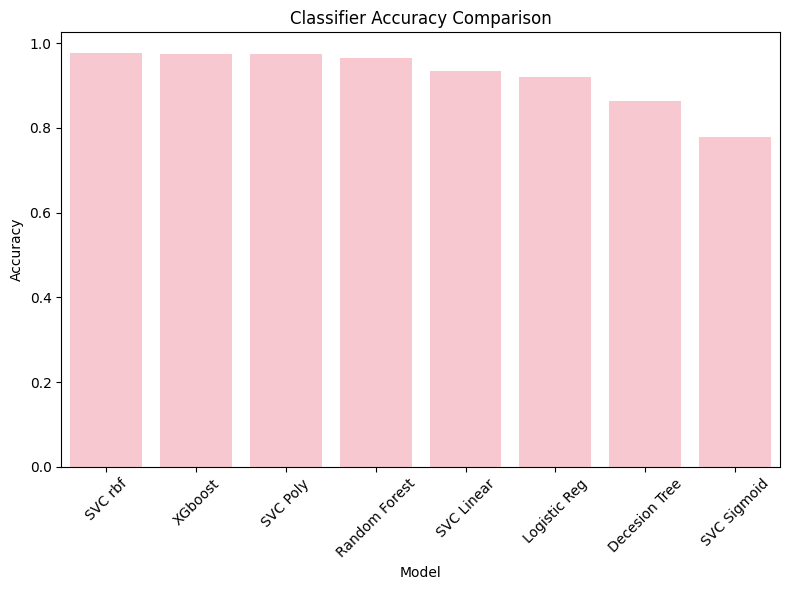

In [25]:
plt.figure(figsize=(8,6))
sns.barplot(data=evaluation_df, x="Model", y="Accuracy", color='pink')
plt.xticks(rotation=45)
plt.title("Classifier Accuracy Comparison")
plt.tight_layout()
plt.show()

# Error Analysis

In [47]:
def misclassified_images(X, y_true, y_pred, model_name, num_samples=9):
#identify misclass indices
    x=np.array(X)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    miss_class_index = np.where(y_true != y_pred)[0]
    
    if len(miss_class_index) == 0:
        print(f"No misclassified samples found for {model_name}.")
        return

#randomly sample a few misclassified examples
    selected_idx = np.random.choice(miss_class_index, size=min(num_samples, len(miss_class_index)), replace=False)
    plt.figure(figsize=(8,8))
    for i, idx in enumerate(selected_idx):
        image = X[idx].reshape(28, 28)
        plt.subplot(3, 3, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"True: {y_true[idx]}, Pred: {y_pred[idx]}")
        plt.axis('off')
    plt.suptitle(f"{model_name} - Misclassified Images", fontsize=16)
    plt.tight_layout()
    plt.show()

In [49]:
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

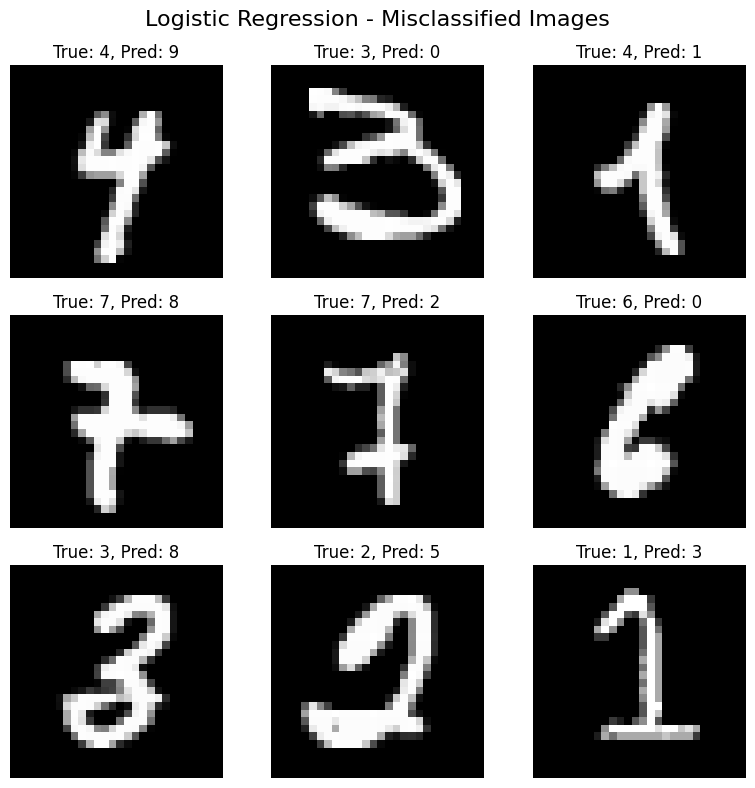

In [52]:
misclassified_images(X_test.values, y_test.values, y_pred_log, "Logistic Regression")

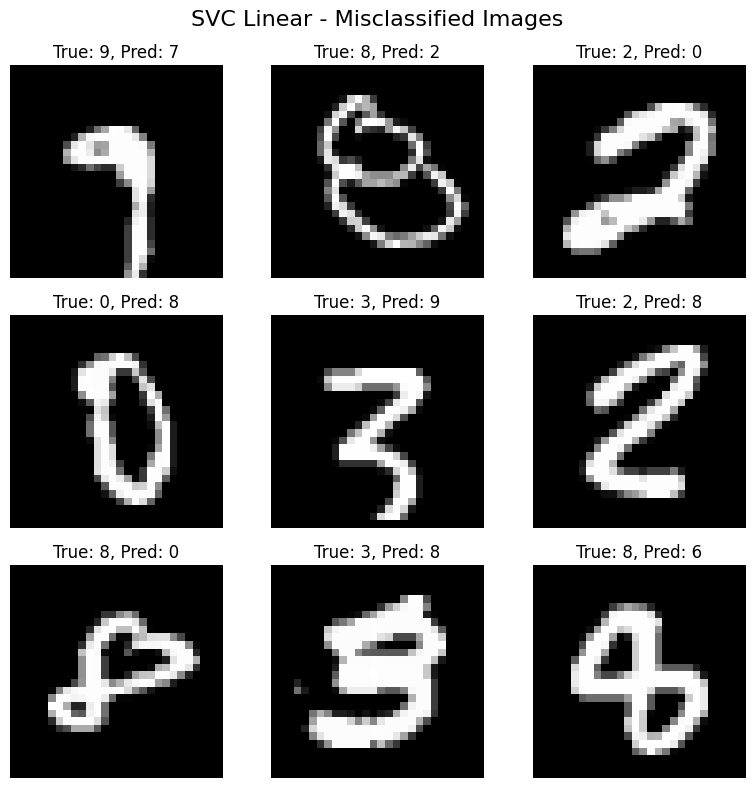

In [54]:
misclassified_images(X_test.values, y_test.values, y_pred_log, "SVC Linear")

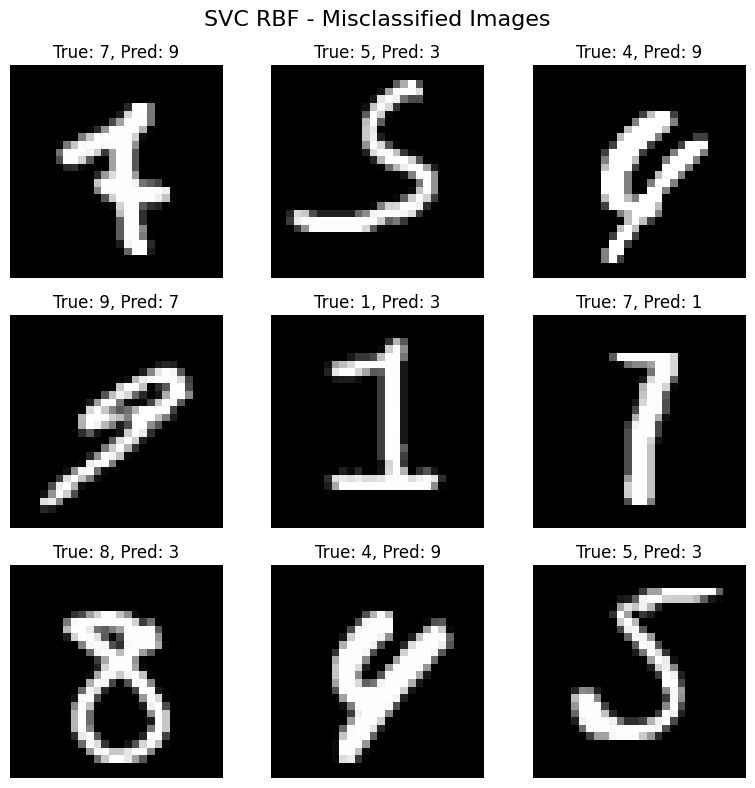

In [55]:
misclassified_images(X_test.values, y_test.values, y_pred_log,"SVC RBF")

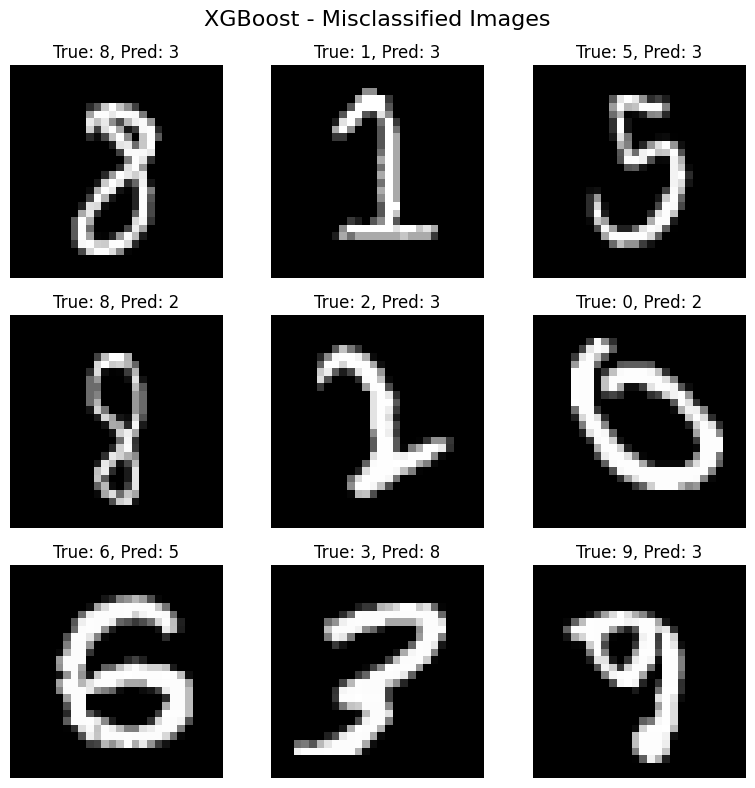

In [56]:
misclassified_images(X_test.values, y_test.values, y_pred_log, "XGBoost")